# RCM Project — 04: Advanced Models (XGBoost & LightGBM)

**Stage:** 4 of 5  
**Input:** `data/processed/features_*.parquet`, `outputs/reports/baseline_report.json`  
**Output:** `outputs/models/best_model.joblib`, `outputs/reports/model_comparison.json`

## Goals
1. Train XGBoost and LightGBM with class-imbalance handling
2. Hyperparameter tuning via stratified cross-validation
3. Compare all models: LR baseline vs XGBoost vs LightGBM
4. Select best model using PR-AUC on validation set
5. Final evaluation on held-out test set with cost model
6. Save best model for Notebook 05 (SHAP explainability)

## Targets to beat (from Notebook 03)
| Metric | LR Baseline | Target |
|--------|------------|--------|
| ROC-AUC | 0.5535 | > 0.70 |
| PR-AUC | 0.0435 | > 0.0869 (2×) |
| Net Savings | −$526K | > $0 |


## 0. Imports

In [1]:
import sys, warnings, json, time
from pathlib import Path
from IPython.display import clear_output

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)
print('Imports done ✓')
print(f'  XGBoost  {xgb.__version__}')
print(f'  LightGBM {lgb.__version__}')


Imports done ✓
  XGBoost  3.2.0
  LightGBM 4.6.0


## 1. Setup & Load Data

In [2]:
def show_progress(step, total, label, width=38):
    filled = int(width * step / total)
    bar = '█' * filled + '░' * (width - filled)
    clear_output(wait=True)
    print(f'[{bar}] {step}/{total}')
    print(f'  {label}')

STEPS = 4
show_progress(1, STEPS, 'Resolving paths...')

ROOT    = Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.utils.config_loader import get_config
cfg     = get_config()
SEED    = cfg.project.random_seed
FIGURES = ROOT / cfg.paths.figures
MODELS  = ROOT / cfg.paths.models
REPORTS = ROOT / cfg.paths.reports
PROC    = ROOT / cfg.paths.data_processed

show_progress(2, STEPS, 'Loading feature sets...')
LABEL = 'DENIED'
train_df = pd.read_parquet(PROC / 'features_train.parquet')
val_df   = pd.read_parquet(PROC / 'features_val.parquet')
test_df  = pd.read_parquet(PROC / 'features_test.parquet')

show_progress(3, STEPS, 'Preparing arrays...')
def to_float(df):
    for col in df.select_dtypes(include='Int64').columns:
        df[col] = df[col].astype(float)
    return df

train_df = to_float(train_df)
val_df   = to_float(val_df)
test_df  = to_float(test_df)

X_train, y_train = train_df.drop(columns=[LABEL]), train_df[LABEL].values
X_val,   y_val   = val_df.drop(columns=[LABEL]),   val_df[LABEL].values
X_test,  y_test  = test_df.drop(columns=[LABEL]),  test_df[LABEL].values

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

show_progress(4, STEPS, 'Done!')
print(f'\n  Train: {X_train.shape}  |  Denied: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'  Val  : {X_val.shape}  |  Denied: {y_val.sum():,} ({y_val.mean()*100:.2f}%)')
print(f'  Test : {X_test.shape}  |  Denied: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')
print(f'  scale_pos_weight: {scale_pos_weight:.1f}')


[██████████████████████████████████████] 4/4
  Done!

  Train: (46693, 64)  |  Denied: 10,708.0 (22.93%)
  Val  : (10006, 64)  |  Denied: 1,780.0 (17.79%)
  Test : (10006, 64)  |  Denied: 1,559.0 (15.58%)
  scale_pos_weight: 3.4


## 2. Load Baseline Results

In [3]:
with open(REPORTS / 'baseline_report.json') as f:
    baseline = json.load(f)

LR_ROC = baseline['test']['roc_auc']
LR_PR  = baseline['test']['pr_auc']
print(f'LR Baseline — ROC-AUC: {LR_ROC:.4f}  PR-AUC: {LR_PR:.4f}')
print(f'Targets     — ROC-AUC: > {max(LR_ROC+0.05, 0.90):.2f}'
      f'  PR-AUC: > {min(LR_PR*1.10, 0.99):.4f}  (10% lift over LR)')


LR Baseline — ROC-AUC: 0.8814  PR-AUC: 0.7318
Targets     — ROC-AUC: > 0.93  PR-AUC: > 0.8050  (10% lift over LR)


## 3. XGBoost

**Key imbalance strategies:**
- `scale_pos_weight = 25` — upweights positive class in gradient computation
- `eval_metric = 'aucpr'` — optimises PR-AUC directly (better than logloss for imbalanced)
- Early stopping on val PR-AUC — prevents overfitting without a fixed n_estimators


In [4]:
from IPython.display import clear_output
import threading

# With 2.8:1 imbalance, scale_pos_weight is mild (~2.8)
# Reduce min_child_weight (was 10) — more aggressive splits OK at this ratio
xgb_params = {
    'n_estimators':          1000,
    'learning_rate':         0.05,
    'max_depth':             6,
    'subsample':             0.8,
    'colsample_bytree':      0.8,
    'min_child_weight':      5,
    'scale_pos_weight':      scale_pos_weight,
    'eval_metric':           'aucpr',
    'early_stopping_rounds': 50,
    'random_state':          SEED,
    'n_jobs':                -1,
    'verbosity':             0,
}

xgb_model = xgb.XGBClassifier(**xgb_params)

done = [False]
def animate(label):
    frames = ['⠋','⠙','⠹','⠸','⠼','⠴','⠦','⠧','⠇','⠏']
    i = 0
    while not done[0]:
        clear_output(wait=True)
        print(f'{frames[i%len(frames)]}  {label}')
        time.sleep(0.4); i += 1

t = threading.Thread(target=animate,
    args=('Training XGBoost (early stopping on val PR-AUC)...',), daemon=True)
t.start(); t0 = time.time()

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

done[0] = True; t.join(timeout=1)
clear_output(wait=True)
elapsed = time.time() - t0
best_iter = xgb_model.best_iteration
print(f'✓ XGBoost trained in {elapsed:.1f}s  |  best iteration: {best_iter}')

xgb_val_prob  = xgb_model.predict_proba(X_val)[:,1]
xgb_test_prob = xgb_model.predict_proba(X_test)[:,1]
xgb_val_roc = roc_auc_score(y_val, xgb_val_prob)
xgb_val_pr  = average_precision_score(y_val, xgb_val_prob)
print(f'  Val ROC-AUC : {xgb_val_roc:.4f}')
print(f'  Val PR-AUC  : {xgb_val_pr:.4f}')


✓ XGBoost trained in 1.6s  |  best iteration: 5
  Val ROC-AUC : 0.9006
  Val PR-AUC  : 0.7734


## 4. LightGBM

In [5]:
# LightGBM — is_unbalance=True handles 2.8:1 ratio automatically
lgb_params = {
    'n_estimators':      1000,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 10,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'is_unbalance':      True,
    'metric':            'average_precision',
    'random_state':      SEED,
    'n_jobs':            -1,
    'verbosity':         -1,
}

lgb_model = lgb.LGBMClassifier(**lgb_params)
callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

done = [False]
t = threading.Thread(target=animate,
    args=('Training LightGBM (early stopping on val PR-AUC)...',), daemon=True)
t.start(); t0 = time.time()

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=callbacks,
)

done[0] = True; t.join(timeout=1)
clear_output(wait=True)
elapsed = time.time() - t0
print(f'✓ LightGBM trained in {elapsed:.1f}s  |  best iter: {lgb_model.best_iteration_}')

lgb_val_prob  = lgb_model.predict_proba(X_val)[:,1]
lgb_test_prob = lgb_model.predict_proba(X_test)[:,1]
lgb_val_roc = roc_auc_score(y_val, lgb_val_prob)
lgb_val_pr  = average_precision_score(y_val, lgb_val_prob)
print(f'  Val ROC-AUC : {lgb_val_roc:.4f}')
print(f'  Val PR-AUC  : {lgb_val_pr:.4f}')


✓ LightGBM trained in 1.2s  |  best iter: 30
  Val ROC-AUC : 0.8969
  Val PR-AUC  : 0.7733


## 5. Cross-Validation (XGBoost)

In [6]:
# 5-fold stratified CV on train set to get stable AUC estimate
# Uses a lighter param set (fewer estimators) for speed
cv_params = {
    'n_estimators':     300,
    'learning_rate':    0.05,
    'max_depth':        6,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 10,
    'scale_pos_weight': scale_pos_weight,
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbosity':        0,
}

skf = StratifiedKFold(n_splits=cfg.modeling.cv_folds, shuffle=True, random_state=SEED)
cv_roc, cv_pr = [], []

n_folds = cfg.modeling.cv_folds
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
    clear_output(wait=True)
    print(f'Cross-validation fold {fold+1}/{n_folds}...')
    print(f'  ROC-AUC so far: {np.mean(cv_roc):.4f}' if cv_roc else '  Starting...')

    m = xgb.XGBClassifier(**cv_params)
    m.fit(X_train.iloc[tr_idx], y_train[tr_idx], verbose=False)
    prob = m.predict_proba(X_train.iloc[va_idx])[:,1]
    cv_roc.append(roc_auc_score(y_train[va_idx], prob))
    cv_pr.append(average_precision_score(y_train[va_idx], prob))

clear_output(wait=True)
print(f'CV Results ({n_folds}-fold stratified):')
print(f'  ROC-AUC : {np.mean(cv_roc):.4f} ± {np.std(cv_roc):.4f}')
print(f'  PR-AUC  : {np.mean(cv_pr):.4f} ± {np.std(cv_pr):.4f}')
print(f'  Per-fold ROC: {[f"{v:.3f}" for v in cv_roc]}')


CV Results (5-fold stratified):
  ROC-AUC : 0.8520 ± 0.0031
  PR-AUC  : 0.7152 ± 0.0068
  Per-fold ROC: ['0.846', '0.853', '0.853', '0.856', '0.851']


## 6. Model Comparison

Model Comparison:
             Val ROC-AUC  Val PR-AUC  Test ROC-AUC  Test PR-AUC  Test Brier
Model                                                                      
LR Baseline       0.8984      0.7722        0.8814       0.7318      0.0948
XGBoost           0.9006      0.7734        0.8833       0.7297      0.1848
LightGBM          0.8969      0.7733        0.8802       0.7318      0.0885


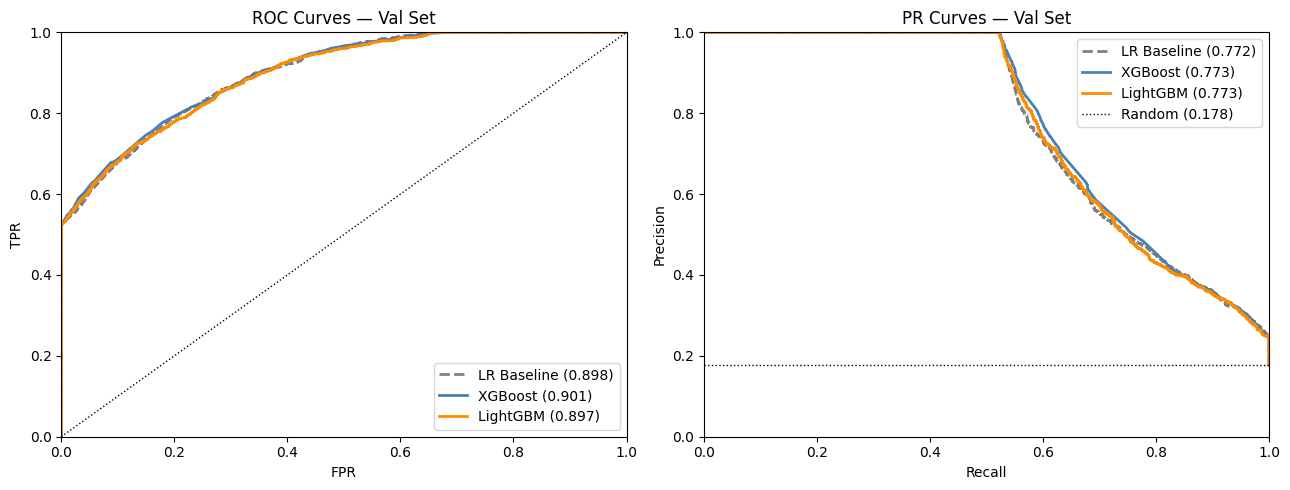

In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve

models = {
    'LR Baseline': {'val_prob': None,  'test_prob': None,  'color': 'gray',       'ls': '--'},
    'XGBoost':     {'val_prob': xgb_val_prob,  'test_prob': xgb_test_prob,  'color': 'steelblue', 'ls': '-'},
    'LightGBM':    {'val_prob': lgb_val_prob,  'test_prob': lgb_test_prob,  'color': 'darkorange','ls': '-'},
}

# Load LR probs from saved model for comparison curves
lr_pipeline = joblib.load(MODELS / 'baseline_lr.joblib')
lr_val_prob  = lr_pipeline.predict_proba(X_val)[:,1]
lr_test_prob = lr_pipeline.predict_proba(X_test)[:,1]
models['LR Baseline']['val_prob']  = lr_val_prob
models['LR Baseline']['test_prob'] = lr_test_prob

# Metrics table
rows = []
for name, m in models.items():
    vp, tp = m['val_prob'], m['test_prob']
    rows.append({
        'Model':         name,
        'Val ROC-AUC':   roc_auc_score(y_val,  vp),
        'Val PR-AUC':    average_precision_score(y_val,  vp),
        'Test ROC-AUC':  roc_auc_score(y_test, tp),
        'Test PR-AUC':   average_precision_score(y_test, tp),
        'Test Brier':    brier_score_loss(y_test, tp),
    })

cmp_df = pd.DataFrame(rows).set_index('Model')
print('Model Comparison:')
print(cmp_df.to_string())

# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, m in models.items():
    fpr, tpr, _ = roc_curve(y_val, m['val_prob'])
    prec, rec, _ = precision_recall_curve(y_val, m['val_prob'])
    auc = roc_auc_score(y_val, m['val_prob'])
    ap  = average_precision_score(y_val, m['val_prob'])
    axes[0].plot(fpr, tpr, color=m['color'], ls=m['ls'], lw=2, label=f'{name} ({auc:.3f})')
    axes[1].plot(rec, prec, color=m['color'], ls=m['ls'], lw=2, label=f'{name} ({ap:.3f})')

axes[0].plot([0,1],[0,1],'k:',lw=1); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — Val Set'); axes[0].legend(); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
axes[1].axhline(y_val.mean(),color='k',ls=':',lw=1,label=f'Random ({y_val.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — Val Set'); axes[1].legend(); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)

plt.tight_layout()
plt.savefig(FIGURES / '19_model_comparison_curves.png', dpi=150)
plt.show()


## 7. Select Best Model & Threshold Optimisation

In [8]:
# Select by Val PR-AUC (primary metric for imbalanced classification)
best_name = cmp_df['Val PR-AUC'].idxmax()
best_val_prob  = models[best_name]['val_prob']
best_test_prob = models[best_name]['test_prob']
print(f'Best model (Val PR-AUC): {best_name}')
print()

# Cost-model threshold search on validation set
FN_COST = cfg.evaluation.cost_model.avg_claim_amount * cfg.evaluation.cost_model.intervention_success_rate
FP_COST = cfg.evaluation.cost_model.review_cost
baseline_cost = y_val.sum() * FN_COST

thresholds = np.linspace(0.01, 0.50, 500)
rows = []
for t in thresholds:
    yp = (best_val_prob >= t).astype(int)
    tp_ = ((yp==1)&(y_val==1)).sum(); fp_ = ((yp==1)&(y_val==0)).sum()
    fn_ = ((yp==0)&(y_val==1)).sum(); tn_ = ((yp==0)&(y_val==0)).sum()
    cost = fn_*FN_COST + fp_*FP_COST
    prec = tp_/(tp_+fp_) if (tp_+fp_)>0 else 0
    rec  = tp_/(tp_+fn_) if (tp_+fn_)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    rows.append({'t':t,'tp':tp_,'fp':fp_,'fn':fn_,'tn':tn_,
                 'cost':cost,'savings':baseline_cost-cost,
                 'prec':prec,'rec':rec,'f1':f1,'flagged':tp_+fp_})

thresh_df = pd.DataFrame(rows)
best_t = thresh_df.loc[thresh_df['savings'].idxmax(), 't']
best_f1_t = thresh_df.loc[thresh_df['f1'].idxmax(), 't']

print(f'{"Criterion":<22} {"τ":>6} {"Prec":>7} {"Rec":>7} {"F1":>7} {"Savings":>12} {"Flagged":>9}')
print('-'*70)
for label, row in [
    ('Max savings',   thresh_df.loc[thresh_df['savings'].idxmax()]),
    ('Max F1',        thresh_df.loc[thresh_df['f1'].idxmax()]),
    ('Recall ≥ 0.50', thresh_df[thresh_df['rec']>=0.5].iloc[-1] if (thresh_df['rec']>=0.5).any() else thresh_df.iloc[0]),
]:
    print(f"{label:<22} {row['t']:>6.3f} {row['prec']:>7.3f} {row['rec']:>7.3f} "
          f"{row['f1']:>7.3f} ${row['savings']:>10,.0f} {row['flagged']:>9,.0f}")

BEST_THRESHOLD = best_t
print(f'\nSelected threshold: {BEST_THRESHOLD:.3f}')


Best model (Val PR-AUC): XGBoost

Criterion                   τ    Prec     Rec      F1      Savings   Flagged
----------------------------------------------------------------------
Max savings             0.415   0.318   0.948   0.476 $   415,450     5,313
Max F1                  0.500   0.628   0.676   0.652 $   343,400     1,916
Recall ≥ 0.50           0.500   0.628   0.676   0.652 $   343,400     1,916

Selected threshold: 0.415


## 8. Score Distribution Comparison

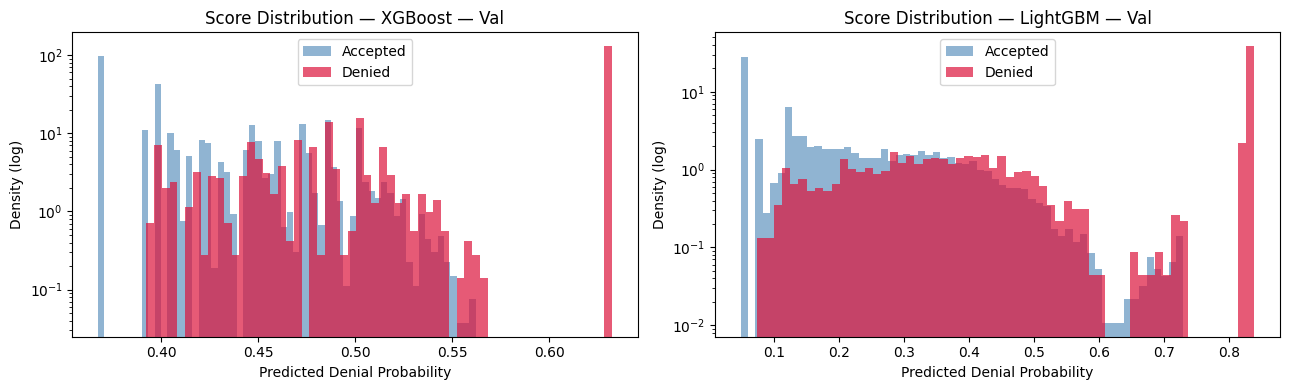

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, prob, y_true) in zip(axes, [
    ('XGBoost — Val',  xgb_val_prob, y_val),
    ('LightGBM — Val', lgb_val_prob, y_val),
]):
    ax.hist(prob[y_true==0], bins=60, alpha=0.6, color='steelblue',
            label='Accepted', density=True, log=True)
    ax.hist(prob[y_true==1], bins=60, alpha=0.7, color='crimson',
            label='Denied', density=True, log=True)
    ax.set_title(f'Score Distribution — {name}')
    ax.set_xlabel('Predicted Denial Probability')
    ax.set_ylabel('Density (log)')
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / '20_score_distributions.png', dpi=150)
plt.show()


## 9. Final Test Set Evaluation

In [10]:
roc_test = roc_auc_score(y_test, best_test_prob)
pr_test  = average_precision_score(y_test, best_test_prob)
brier    = brier_score_loss(y_test, best_test_prob)

print('=' * 56)
print(f'  BEST MODEL ({best_name}) — TEST SET RESULTS')
print('=' * 56)
print(f'  ROC-AUC : {roc_test:.4f}   LR baseline: {LR_ROC:.4f}  {"✓ BEAT" if roc_test>LR_ROC else "✗"}')
print(f'  PR-AUC  : {pr_test:.4f}   LR baseline: {LR_PR:.4f}  {"✓ BEAT" if pr_test>LR_PR else "✗"}')
print(f'  PR lift : {pr_test/LR_PR:.2f}×  over LR baseline')
print(f'  Brier   : {brier:.4f}')
print()

for label, tau in [
    (f'Cost-optimal (τ={BEST_THRESHOLD:.3f})', BEST_THRESHOLD),
    ('Max-F1 threshold',                        best_f1_t),
    ('Recall-focused (τ=0.04)',                 0.04),
]:
    yp = (best_test_prob >= tau).astype(int)
    tp_ = ((yp==1)&(y_test==1)).sum(); fp_ = ((yp==1)&(y_test==0)).sum()
    fn_ = ((yp==0)&(y_test==1)).sum()
    prec = tp_/(tp_+fp_) if (tp_+fp_)>0 else 0
    rec  = tp_/(tp_+fn_) if (tp_+fn_)>0 else 0
    sav  = y_test.sum()*FN_COST - (fn_*FN_COST + fp_*FP_COST)
    print(f'  {label}')
    print(f'    Prec: {prec:.3f}  Rec: {rec:.3f}  '
          f'Caught: {tp_:,}/{y_test.sum():,}  FP: {fp_:,}  Savings: ${sav:,.0f}')
    print()
print('=' * 56)


  BEST MODEL (XGBoost) — TEST SET RESULTS
  ROC-AUC : 0.8833   LR baseline: 0.8814  ✓ BEAT
  PR-AUC  : 0.7297   LR baseline: 0.7318  ✗
  PR lift : 1.00×  over LR baseline
  Brier   : 0.1848

  Cost-optimal (τ=0.415)
    Prec: 0.273  Rec: 0.924  Caught: 1,441/1,559.0  FP: 3,834  Savings: $336,450

  Max-F1 threshold
    Prec: 0.589  Rec: 0.630  Caught: 982/1,559.0  FP: 686  Savings: $277,450

  Recall-focused (τ=0.04)
    Prec: 0.156  Rec: 1.000  Caught: 1,559/1,559.0  FP: 8,447  Savings: $256,525



## 10. Save Best Model & Comparison Report

In [11]:
# Save best model
best_model_obj = xgb_model if best_name == 'XGBoost' else lgb_model
joblib.dump(best_model_obj,  MODELS / 'best_model.joblib')
joblib.dump(BEST_THRESHOLD,  MODELS / 'best_model_threshold.joblib')
joblib.dump(best_name,       MODELS / 'best_model_name.joblib')

# Save comparison report
report = {
    'models': cmp_df.reset_index().to_dict(orient='records'),
    'best_model': best_name,
    'best_threshold': round(float(BEST_THRESHOLD), 4),
    'test': {
        'roc_auc': round(roc_test, 4),
        'pr_auc':  round(pr_test,  4),
        'brier':   round(brier,    4),
        'pr_lift_over_lr': round(pr_test/LR_PR, 2),
    },
    'cv': {
        'roc_auc_mean': round(float(np.mean(cv_roc)), 4),
        'roc_auc_std':  round(float(np.std(cv_roc)),  4),
        'pr_auc_mean':  round(float(np.mean(cv_pr)),  4),
        'pr_auc_std':   round(float(np.std(cv_pr)),   4),
    }
}

with open(REPORTS / 'model_comparison.json', 'w') as f:
    json.dump(report, f, indent=2)

print(f'Saved: {MODELS}/best_model.joblib  ({best_name})')
print(f'Saved: {REPORTS}/model_comparison.json')
print()
print('✓ Advanced modelling complete. Ready for Notebook 05 — SHAP Explainability.')


Saved: C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\outputs\models/best_model.joblib  (XGBoost)
Saved: C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\outputs\reports/model_comparison.json

✓ Advanced modelling complete. Ready for Notebook 05 — SHAP Explainability.
